In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("../data/processed/langchain_global_clean.csv")

### Çoklu Anahtar Kelime için XGBoost ile Zaman Serisi Tahmini

Bu notebook, Google Trends verisindeki her sayısal anahtar kelime sütununu ayrı bir zaman serisi olarak ele alır.

Örneğin veri `Python`, `SQL` sütunlarını içeriyorsa her biri için ayrı XGBoost ve LightGBM modeli kurulur.

##### Lag Feature (Gecikme Özelliği) nedir?

Lag Feature, geçmiş gözlemlerin mevcut değeri tahmin etmek için özellik olarak kullanılmasıdır. Haftalık veride örneğin bir anahtar kelimenin önceki 1, 2 ve 4 haftadaki Google Trends skorları model girdisi olarak kullanılabilir.

Bu notebookta her anahtar kelime için:
- `lag_1`
- `lag_2`
- `lag_4`
- `rolling_mean_4`

özellikleri ayrı ayrı oluşturulur.


In [3]:
df.head()

,date,Python,SQL
0,2023-08-06,62,31
1,2023-08-13,62,30
2,2023-08-20,66,30
3,2023-08-27,67,29
4,2023-09-03,68,29


In [4]:
## Tarih sütununu datetime formatına çeviriyoruz.

df["date"] = pd.to_datetime(
    df["date"]
)


## Zaman serisini kronolojik olarak sıralıyoruz.

df = (
    df
    .sort_values("date")
    .reset_index(drop=True)
)

df.tail()

,date,Python,SQL
153,2026-07-12,58,20
154,2026-07-19,61,25
155,2026-07-26,62,20
156,2026-08-02,57,18
157,2026-08-09,48,17


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    158 non-null    datetime64[us]
 1   Python  158 non-null    int64         
 2   SQL     158 non-null    int64         
dtypes: datetime64[us](1), int64(2)
memory usage: 3.8 KB


### Lag Feature (Gecikme Özelliği)

Zaman serilerinde geleceği tahmin ederken yalnızca geçmişte bilinen değerleri kullanmak gerekir.

Bu veri yapısında `Python`, `SQL` gibi sütunların her biri ayrı bir hedef zaman serisidir. Bu nedenle tek bir `trend_score` sütunu kullanmak yerine her anahtar kelime için ayrı lag özellikleri ve ayrı model oluşturuyoruz.

`rolling_mean_4` hesabında da mevcut haftayı kullanmıyoruz; önce `shift(1)` uygulayıp yalnızca geçmiş 4 haftanın ortalamasını modele veriyoruz.


In [6]:
## date dışındaki sayısal sütunları otomatik olarak anahtar kelime kabul ediyoruz.
## Böylece yeni bir anahtar kelime sütunu eklendiğinde kodu elle değiştirmek gerekmez.

keywords = [
    col for col in df.columns
    if col != "date" and pd.api.types.is_numeric_dtype(df[col])
]

if not keywords:
    raise ValueError("date dışında sayısal bir anahtar kelime sütunu bulunamadı.")

feature_columns = [
    "lag_1",
    "lag_2",
    "lag_4",
    "rolling_mean_4"
]

def create_lag_features(data, keyword):
    temp = (
        data[["date", keyword]]
        .dropna()
        .sort_values("date")
        .reset_index(drop=True)
        .rename(columns={keyword: "y"})
    )

    ## Yaklaşık 7 gün önceki değer
    temp["lag_1"] = temp["y"].shift(1)

    ## Yaklaşık 14 gün önceki değer
    temp["lag_2"] = temp["y"].shift(2)

    ## Yaklaşık 28 gün önceki değer
    temp["lag_4"] = temp["y"].shift(4)

    ## Mevcut haftayı dahil etmeden geçmiş 4 haftanın ortalaması
    temp["rolling_mean_4"] = (
        temp["y"]
        .shift(1)
        .rolling(window=4)
        .mean()
    )

    return temp

feature_dfs = {
    keyword: create_lag_features(df, keyword)
    for keyword in keywords
}

print("Modellenecek anahtar kelimeler:", keywords)


Modellenecek anahtar kelimeler: ['Python', 'SQL']


In [7]:
## Örnek olarak ilk anahtar kelimenin oluşturulan lag özelliklerini kontrol ediyoruz.

sample_keyword = keywords[0]

print("Örnek anahtar kelime:", sample_keyword)
feature_dfs[sample_keyword].head(10)


Örnek anahtar kelime: Python


,date,y,lag_1,lag_2,lag_4,rolling_mean_4
0,2023-08-06,62,NaN,NaN,NaN,NaN
1,2023-08-13,62,62.0,NaN,NaN,NaN
2,2023-08-20,66,62.0,62.0,NaN,NaN
3,2023-08-27,67,66.0,62.0,NaN,NaN
4,2023-09-03,68,67.0,66.0,62.0,64.25
5,2023-09-10,71,68.0,67.0,62.0,65.75
6,2023-09-17,71,71.0,68.0,66.0,68.00
7,2023-09-24,67,71.0,71.0,67.0,69.25
8,2023-10-01,72,67.0,71.0,68.0,69.25
9,2023-10-08,72,72.0,67.0,71.0,70.25


In [8]:
## Lag işlemleri nedeniyle oluşan eksik satırları her seri için ayrı temizliyoruz.

clean_dfs = {
    keyword: feature_dfs[keyword].dropna().reset_index(drop=True)
    for keyword in keywords
}


In [9]:
## Örnek temizlenmiş veri.
clean_dfs[sample_keyword].head()


,date,y,lag_1,lag_2,lag_4,rolling_mean_4
0,2023-09-03,68,67.0,66.0,62.0,64.25
1,2023-09-10,71,68.0,67.0,62.0,65.75
2,2023-09-17,71,71.0,68.0,66.0,68.00
3,2023-09-24,67,71.0,71.0,67.0,69.25
4,2023-10-01,72,67.0,71.0,68.0,69.25


In [10]:
## Her anahtar kelime için X ve y yapılarını ayrı tutuyoruz.

X_by_keyword = {
    keyword: clean_dfs[keyword][feature_columns].copy()
    for keyword in keywords
}

y_by_keyword = {
    keyword: clean_dfs[keyword]["y"].copy()
    for keyword in keywords
}


In [11]:
## Train-Test ayrımı
## Son 4 gözlemi test, geri kalanını train olarak kullanıyoruz.
## Zaman serisi olduğu için shuffle yapılmaz.

forecast_steps = 4

X_train = {}
X_test = {}
y_train = {}
y_test = {}
test_dates = {}

for keyword in keywords:

    if len(clean_dfs[keyword]) <= forecast_steps:
        raise ValueError(
            f"{keyword} için train/test ayırmaya yetecek kadar gözlem yok."
        )

    X_train[keyword] = X_by_keyword[keyword].iloc[:-forecast_steps].copy()
    X_test[keyword] = X_by_keyword[keyword].iloc[-forecast_steps:].copy()

    y_train[keyword] = y_by_keyword[keyword].iloc[:-forecast_steps].copy()
    y_test[keyword] = y_by_keyword[keyword].iloc[-forecast_steps:].copy()

    test_dates[keyword] = (
        clean_dfs[keyword]["date"]
        .iloc[-forecast_steps:]
        .reset_index(drop=True)
    )

    print(
        f"{keyword}: "
        f"Train={X_train[keyword].shape}, "
        f"Test={X_test[keyword].shape}"
    )


Python: Train=(150, 4), Test=(4, 4)
SQL: Train=(150, 4), Test=(4, 4)


In [12]:
!pip install xgboost

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)


### XGBoost

Her anahtar kelime için ayrı bir XGBoost regresyon modeli kuruyoruz.

Test dönemini gerçek bir çok-adımlı gelecek tahmini gibi değerlendirmek için tahminleri **recursive** biçimde üretiyoruz. Yani ikinci test haftasının lag değerlerinde birinci test haftasının gerçek değerini kullanmak yerine modelin bir önceki tahminini kullanıyoruz. Böylece geleceğe ait gerçek değerlerin özelliklere sızmasını önlüyoruz.


In [13]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [14]:
## Her anahtar kelime için ayrı XGBoost modeli oluşturuyoruz.

xgb_models = {
    keyword: xgb.XGBRegressor(random_state=42)
    for keyword in keywords
}


In [15]:
## Modelleri kendi train verileriyle eğitiyoruz.

for keyword in keywords:
    xgb_models[keyword].fit(
        X_train[keyword],
        y_train[keyword]
    )


In [16]:
## Çok-adımlı tahmin sırasında test döneminin gerçek değerlerini lag olarak kullanmamak için
## recursive forecast fonksiyonu oluşturuyoruz.

def recursive_forecast(model, history_values, steps):
    history = list(map(float, history_values))
    predictions = []

    if len(history) < 4:
        raise ValueError("Recursive tahmin için en az 4 geçmiş gözlem gerekir.")

    for _ in range(steps):
        features = pd.DataFrame(
            [{
                "lag_1": history[-1],
                "lag_2": history[-2],
                "lag_4": history[-4],
                "rolling_mean_4": np.mean(history[-4:])
            }],
            columns=feature_columns
        )

        prediction = float(model.predict(features)[0])

        predictions.append(prediction)
        history.append(prediction)

    return np.array(predictions)


## Her anahtar kelime için XGBoost test tahminlerini üretiyoruz.

y_pred_xgb = {}

for keyword in keywords:
    y_pred_xgb[keyword] = recursive_forecast(
        xgb_models[keyword],
        y_train[keyword].values,
        forecast_steps
    )

print("Örnek anahtar kelime:", sample_keyword)
print("Gerçek Değerler (Test):", y_test[sample_keyword].values)
print("XGBoost Tahminleri    :", y_pred_xgb[sample_keyword])


Örnek anahtar kelime: Python
Gerçek Değerler (Test): [61 62 57 48]
XGBoost Tahminleri    : [62.84423447 59.37823868 62.84904099 62.43536377]


In [17]:
## Her anahtar kelime için XGBoost MAE ve RMSE hesaplıyoruz.

xgb_metric_rows = []

for keyword in keywords:
    mae_xgb = mean_absolute_error(
        y_test[keyword],
        y_pred_xgb[keyword]
    )

    rmse_xgb = root_mean_squared_error(
        y_test[keyword],
        y_pred_xgb[keyword]
    )

    xgb_metric_rows.append({
        "keyword": keyword,
        "model": "XGBoost",
        "MAE": mae_xgb,
        "RMSE": rmse_xgb
    })

xgb_metrics_df = (
    pd.DataFrame(xgb_metric_rows)
    .sort_values("MAE")
    .reset_index(drop=True)
)

xgb_metrics_df.round(2)


,keyword,model,MAE,RMSE
0,SQL,XGBoost,3.50,3.78
1,Python,XGBoost,6.19,7.95


In [18]:
## XGBoost için gerçek ve tahmin edilen test değerlerini tek tabloda topluyoruz.

xgb_test_results = pd.concat(
    [
        pd.DataFrame({
            "keyword": keyword,
            "date": test_dates[keyword],
            "actual": y_test[keyword].values,
            "predicted": y_pred_xgb[keyword]
        })
        for keyword in keywords
    ],
    ignore_index=True
)

xgb_test_results


,keyword,date,actual,predicted
0,Python,2026-07-19,61,62.844234
1,Python,2026-07-26,62,59.378239
2,Python,2026-08-02,57,62.849041
3,Python,2026-08-09,48,62.435364
4,SQL,2026-07-19,25,22.658110
5,SQL,2026-07-26,20,22.076338
6,SQL,2026-08-02,18,21.983631
7,SQL,2026-08-09,17,22.602444


### LightGBM

LightGBM için de aynı veri hazırlama ve recursive test mantığını kullanıyoruz. Böylece XGBoost ve LightGBM karşılaştırması aynı train/test koşulları altında yapılır.


In [19]:
!pip install lightgbm

  Using cached lightgbm-4.7.0-py3-none-win_amd64.whl.metadata (18 kB)
Using cached lightgbm-4.7.0-py3-none-win_amd64.whl (1.4 MB)


In [20]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

In [21]:
## Her anahtar kelime için ayrı LightGBM modeli tanımlıyoruz.

lgb_models = {
    keyword: lgb.LGBMRegressor(
        random_state=42,
        verbosity=-1
    )
    for keyword in keywords
}


In [22]:
## LightGBM modellerini kendi train verileriyle eğitiyoruz.

for keyword in keywords:
    lgb_models[keyword].fit(
        X_train[keyword],
        y_train[keyword]
    )


In [23]:
## Her anahtar kelime için recursive LightGBM test tahmini üretiyoruz.

y_pred_lgb = {}

for keyword in keywords:
    y_pred_lgb[keyword] = recursive_forecast(
        lgb_models[keyword],
        y_train[keyword].values,
        forecast_steps
    )


In [24]:
## Örnek anahtar kelimenin LightGBM test tahminlerini gösteriyoruz.

print("Örnek anahtar kelime:", sample_keyword)
print("Gerçek Değerler (Test):", y_test[sample_keyword].values)
print("LightGBM Tahminleri   :", y_pred_lgb[sample_keyword])


Örnek anahtar kelime: Python
Gerçek Değerler (Test): [61 62 57 48]
LightGBM Tahminleri   : [66.33607174 68.51948472 70.55041457 70.78424095]


In [25]:
## LightGBM metriklerini hesaplıyor ve XGBoost ile karşılaştırıyoruz.

lgb_metric_rows = []

for keyword in keywords:
    mae_lgb = mean_absolute_error(
        y_test[keyword],
        y_pred_lgb[keyword]
    )

    rmse_lgb = root_mean_squared_error(
        y_test[keyword],
        y_pred_lgb[keyword]
    )

    lgb_metric_rows.append({
        "keyword": keyword,
        "model": "LightGBM",
        "MAE": mae_lgb,
        "RMSE": rmse_lgb
    })

lgb_metrics_df = pd.DataFrame(lgb_metric_rows)

model_comparison_df = (
    pd.concat(
        [xgb_metrics_df, lgb_metrics_df],
        ignore_index=True
    )
    .sort_values(["keyword", "MAE"])
    .reset_index(drop=True)
)

model_comparison_df.round(2)


,keyword,model,MAE,RMSE
0,Python,XGBoost,6.19,7.95
1,Python,LightGBM,12.05,13.91
2,SQL,LightGBM,3.23,3.37
3,SQL,XGBoost,3.50,3.78


In [26]:
import joblib
import os


In [27]:
## joblib Python paketidir; os ise Python'un standart kütüphanesidir.
## Gerekirse yalnızca joblib kurulabilir.
# !pip install joblib


In [28]:
## Eğitilmiş tüm anahtar kelime modellerini tek dosyada saklıyoruz.

os.makedirs("../models", exist_ok=True)

xgb_model_path = "../models/xgboost_models_multi_keyword.pkl"
lgb_model_path = "../models/lightgbm_models_multi_keyword.pkl"

joblib.dump(
    {
        "models": xgb_models,
        "keywords": keywords,
        "feature_columns": feature_columns,
        "forecast_steps": forecast_steps
    },
    xgb_model_path
)

joblib.dump(
    {
        "models": lgb_models,
        "keywords": keywords,
        "feature_columns": feature_columns,
        "forecast_steps": forecast_steps
    },
    lgb_model_path
)

print(f"XGBoost modelleri kaydedildi: {xgb_model_path}")
print(f"LightGBM modelleri kaydedildi: {lgb_model_path}")


XGBoost modelleri kaydedildi: ../models/xgboost_models_multi_keyword.pkl
LightGBM modelleri kaydedildi: ../models/lightgbm_models_multi_keyword.pkl


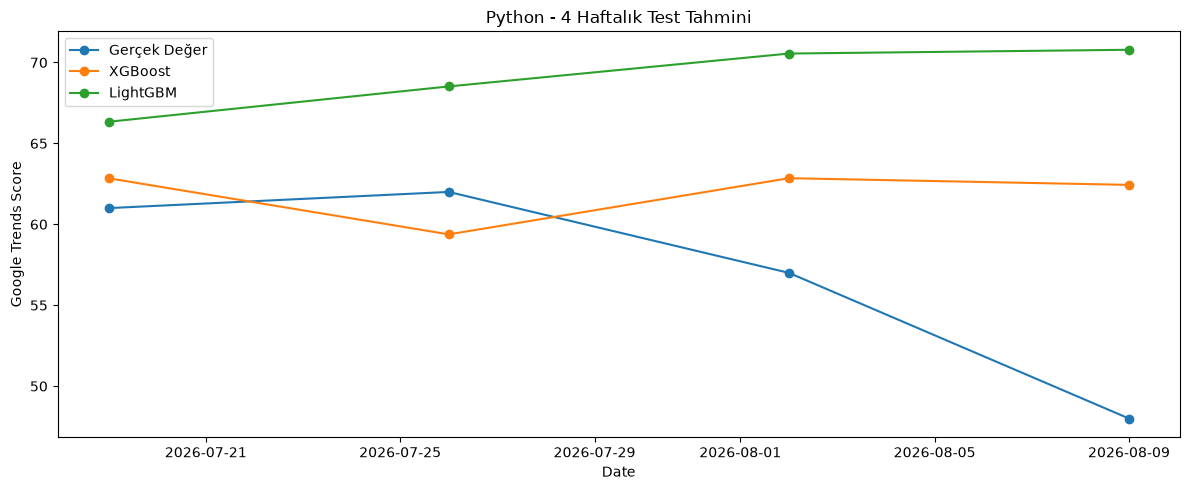

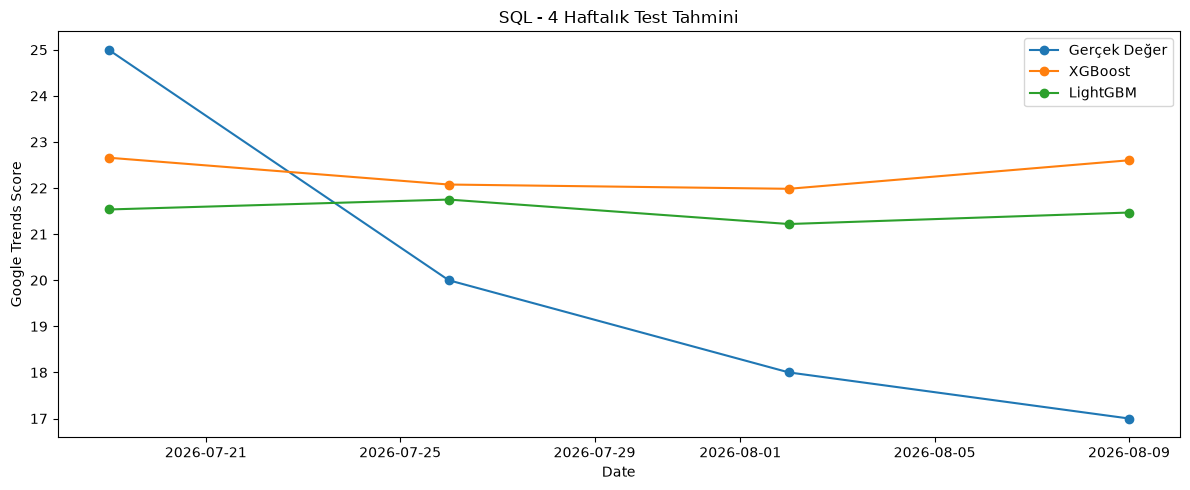

In [29]:
## Test döneminde her anahtar kelime için gerçek değerleri,
## XGBoost ve LightGBM tahminlerini karşılaştırıyoruz.

for keyword in keywords:

    plt.figure(figsize=(12, 5))

    plt.plot(
        test_dates[keyword],
        y_test[keyword].values,
        marker="o",
        label="Gerçek Değer"
    )

    plt.plot(
        test_dates[keyword],
        y_pred_xgb[keyword],
        marker="o",
        label="XGBoost"
    )

    plt.plot(
        test_dates[keyword],
        y_pred_lgb[keyword],
        marker="o",
        label="LightGBM"
    )

    plt.title(f"{keyword} - 4 Haftalık Test Tahmini")
    plt.xlabel("Date")
    plt.ylabel("Google Trends Score")
    plt.legend()
    plt.tight_layout()
    plt.show()


### Yaklaşık 30 Günlük Gelecek Tahmini

Test değerlendirmesi bittikten sonra modelleri her anahtar kelimenin **tüm geçmiş verisi** üzerinde yeniden eğitiyoruz. Veri haftalık olduğu için yaklaşık 30 gün için 4 ileri hafta recursive olarak tahmin edilir.


In [30]:
## Final eğitim verilerini hazırlıyor ve modelleri tüm geçmiş veriyle yeniden eğitiyoruz.

final_xgb_models = {}
final_lgb_models = {}

for keyword in keywords:
    final_X = clean_dfs[keyword][feature_columns]
    final_y = clean_dfs[keyword]["y"]

    final_xgb_models[keyword] = xgb.XGBRegressor(
        random_state=42
    )

    final_lgb_models[keyword] = lgb.LGBMRegressor(
        random_state=42,
        verbosity=-1
    )

    final_xgb_models[keyword].fit(final_X, final_y)
    final_lgb_models[keyword].fit(final_X, final_y)


In [31]:
## Her anahtar kelime için 4 haftalık recursive gelecek tahmini üretiyoruz.

future_rows = []

for keyword in keywords:

    raw_history = (
        df[["date", keyword]]
        .dropna()
        .sort_values("date")
        .reset_index(drop=True)
    )

    history_values = raw_history[keyword].astype(float).values
    last_date = raw_history["date"].max()

    future_dates = pd.date_range(
        start=last_date + pd.Timedelta(days=7),
        periods=forecast_steps,
        freq="7D"
    )

    xgb_future = recursive_forecast(
        final_xgb_models[keyword],
        history_values,
        forecast_steps
    )

    lgb_future = recursive_forecast(
        final_lgb_models[keyword],
        history_values,
        forecast_steps
    )

    for date, xgb_pred, lgb_pred in zip(
        future_dates,
        xgb_future,
        lgb_future
    ):
        future_rows.append({
            "keyword": keyword,
            "date": date,
            "XGBoost": xgb_pred,
            "LightGBM": lgb_pred
        })

future_forecast_df = pd.DataFrame(future_rows)

future_forecast_df[["XGBoost", "LightGBM"]] = (
    future_forecast_df[["XGBoost", "LightGBM"]]
    .round(2)
)

future_forecast_df


,keyword,date,XGBoost,LightGBM
0,Python,2026-08-16,44.22,50.41
1,Python,2026-08-23,60.12,51.66
2,Python,2026-08-30,60.84,52.33
3,Python,2026-09-06,62.27,55.35
4,SQL,2026-08-16,18.36,21.00
5,SQL,2026-08-23,17.10,21.30
6,SQL,2026-08-30,17.08,21.30
7,SQL,2026-09-06,17.08,21.30


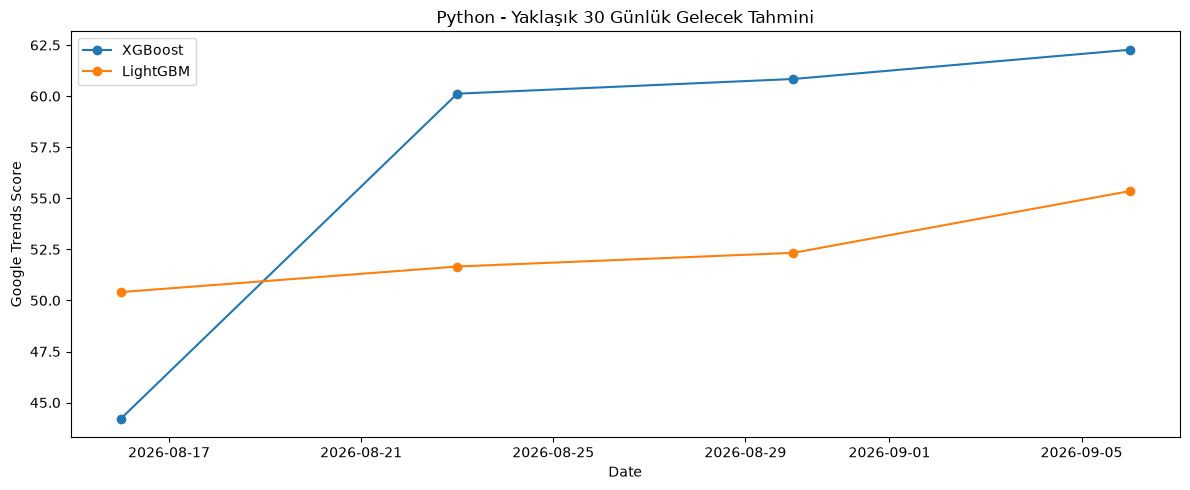

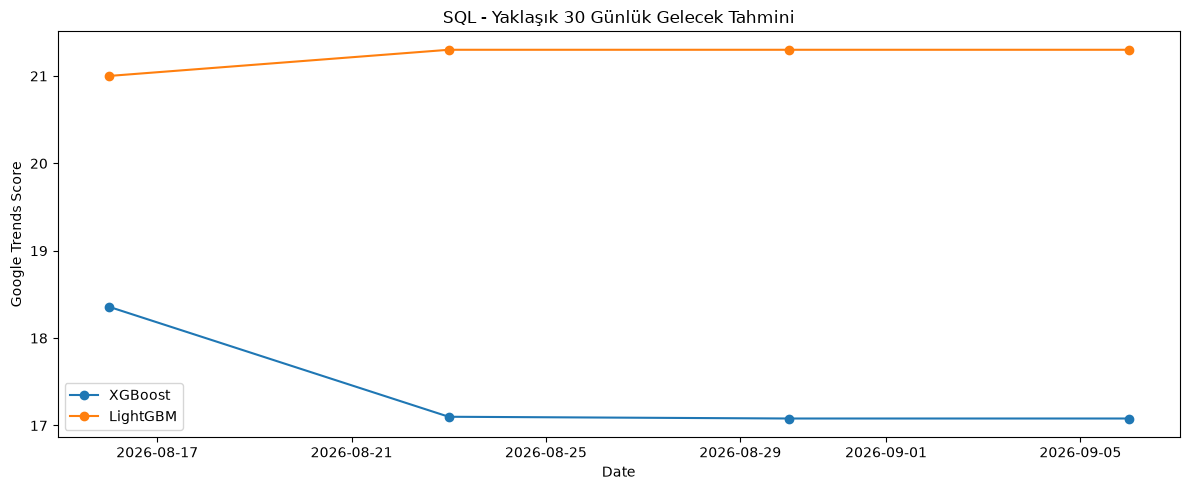

In [32]:
## Her anahtar kelimenin gelecekteki XGBoost ve LightGBM tahminlerini çiziyoruz.

for keyword in keywords:

    keyword_future = future_forecast_df[
        future_forecast_df["keyword"] == keyword
    ]

    plt.figure(figsize=(12, 5))

    plt.plot(
        keyword_future["date"],
        keyword_future["XGBoost"],
        marker="o",
        label="XGBoost"
    )

    plt.plot(
        keyword_future["date"],
        keyword_future["LightGBM"],
        marker="o",
        label="LightGBM"
    )

    plt.title(f"{keyword} - Yaklaşık 30 Günlük Gelecek Tahmini")
    plt.xlabel("Date")
    plt.ylabel("Google Trends Score")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [33]:
## Son olarak bütün anahtar kelimelerin gelecek tahmin tablosunu gösteriyoruz.

future_forecast_df


,keyword,date,XGBoost,LightGBM
0,Python,2026-08-16,44.22,50.41
1,Python,2026-08-23,60.12,51.66
2,Python,2026-08-30,60.84,52.33
3,Python,2026-09-06,62.27,55.35
4,SQL,2026-08-16,18.36,21.00
5,SQL,2026-08-23,17.10,21.30
6,SQL,2026-08-30,17.08,21.30
7,SQL,2026-09-06,17.08,21.30
